In [36]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline     
# sns.set(color_codes=True)

### EDA with Car Data

In [3]:
df = pd.read_csv("data/car_data.csv")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [ ]:
df.dtypes

In [ ]:
df = df.drop(['Engine Fuel Type', 'Vehicle Style', 'Popularity', 'Market Category'], axis=1)
df.head()

In [ ]:
# Rename column
df = df.rename(columns={'Engine HP':'HP', 'Engine Cylinders':'Cylinders', 'Number of Doors':'Total_Doors', 'Transmission Type':'Transmission'
                        , 'Vehicle Size':'Vehicle_Size', 'highway MPG':'Highway_Mileage', 'city mpg':'City_Mileage'
                       , 'MSRP':'Price'})

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
# Check duplicate rows count
duplicat_rows = df[df.duplicated()]
duplicat_rows.shape

In [ ]:
df.count()

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

In [ ]:
df.count()

In [ ]:
# Print missing values and will drop incase this number is small
print(df.isnull().sum())

In [ ]:
df = df.dropna()
df.count()

In [ ]:
df.describe()

In [ ]:
# Check outliers using boxplots
sns.boxplot(df['Highway_Mileage'])

In [ ]:
sns.boxplot(df['City_Mileage'])

In [ ]:
sns.boxplot(df['Price'])

In [ ]:
sns.boxplot(df['HP'])

In [ ]:
sns.boxplot(df['Cylinders'])

In [ ]:
# Remove outliers using IQR
df_numerical = df.select_dtypes(include=[int, float])
Q1 = df_numerical.quantile(0.25)
Q3 = df_numerical.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

In [ ]:
df_numerical = df_numerical[~((df_numerical < (Q1 - 1.5 * IQR)) | (df_numerical > (Q3 + 1.5 * IQR))).any(axis=1)]
df_numerical.shape

In [ ]:
plt.figure(figsize=(10, 5))
c = df_numerical.corr()
sns.heatmap(c, cmap='BrBG', annot=True)
c

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df_numerical['HP'], df_numerical['Price'])
ax.set_xlabel('HP')
ax.set_ylabel('Price')

### EDA with House Data

In [12]:
house_df = pd.read_csv("data/house_prices.csv")
house_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [13]:
house_df.shape

(1460, 81)

In [14]:
column_needs_to_drop = []

# identify columns those have less than 30% data
for col in house_df.columns:
    if house_df[col].count()/len(house_df) <= 0.3:
        column_needs_to_drop.append(col)
column_needs_to_drop

['Alley', 'PoolQC', 'Fence', 'MiscFeature']

In [15]:
# drop 'Alley', 'PoolQC', 'Fence', 'MiscFeature' these columns
house_df = house_df.drop(columns=column_needs_to_drop)
house_df.shape

(1460, 77)

In [16]:
# check duplicate rows
duplicat_rows = house_df[house_df.duplicated()]
duplicat_rows.shape

(0, 77)

In [19]:
# Print missing values and will drop incase this number is small
null_counts = house_df.isnull().sum()
sorted_null_counts = null_counts.sort_values(ascending=False)
sorted_null_counts

MasVnrType     872
FireplaceQu    690
LotFrontage    259
GarageCond      81
GarageYrBlt     81
              ... 
BsmtUnfSF        0
TotalBsmtSF      0
MSSubClass       0
HeatingQC        0
SalePrice        0
Length: 77, dtype: int64

In [22]:
house_df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

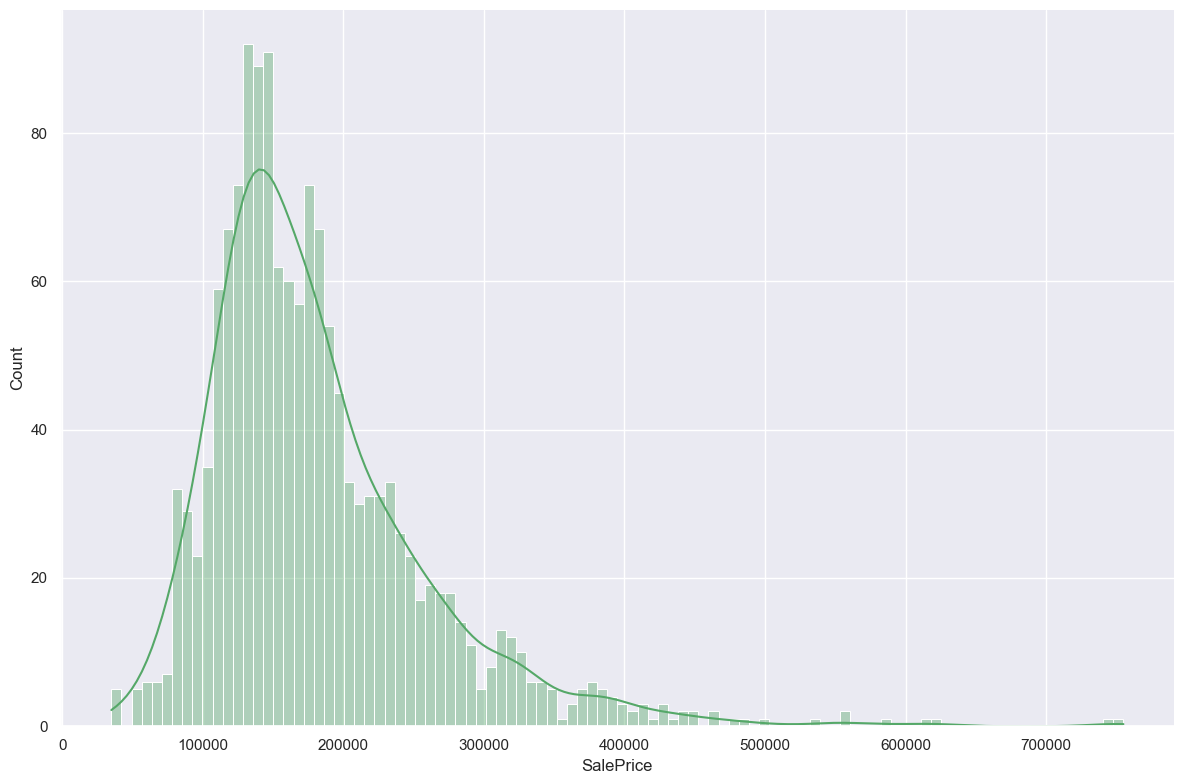

In [39]:
# check how house price is distributed
sns.displot(house_df['SalePrice'], kind='hist', bins=100, kde=True, alpha=0.4, color='g', height=8, aspect=1.5)

In [40]:
# List all the data types of data
list(set(house_df.dtypes.tolist()))

[dtype('int64'), dtype('O'), dtype('float64')]

In [43]:
df_num = house_df.select_dtypes(include=['int', 'float'])
df_num.shape

(1460, 38)

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

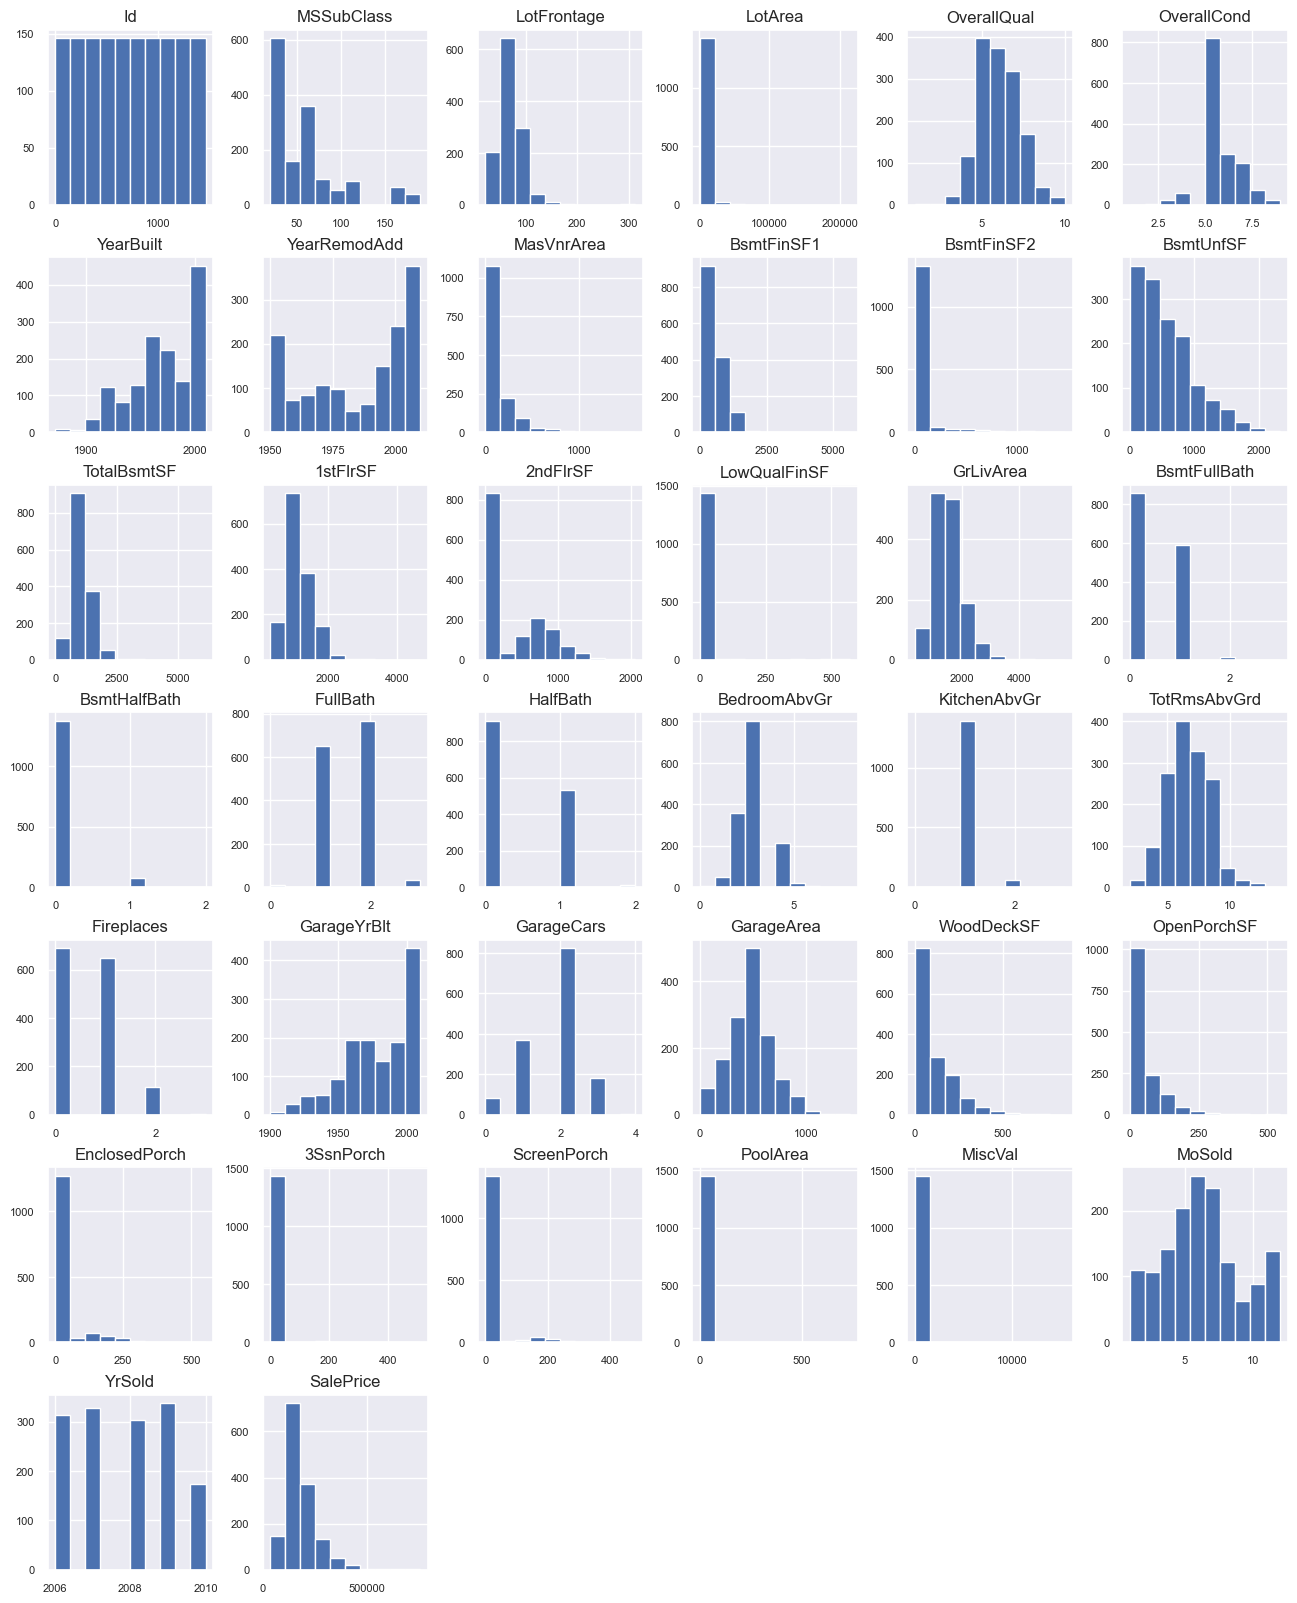

In [44]:
df_num.hist(figsize=(16, 20), xlabelsize=8, ylabelsize=8)

Features such as `1stFlrSF`, `TotalBsmtSF`, `LotFrontage`, `GrLiveArea`... seems to share a similar distribution to the one we have with `SalePrice`.

In [56]:
df_num_corr = df_num.corr()['SalePrice'][:-1]
df_num_corr
golden_features_list = df_num_corr[abs(df_num_corr) > 0.5].sort_values(ascending=False)
print("There is {} strongly correlated values with SalePrice:\n{}".format(len(golden_features_list), golden_features_list))

There is 10 strongly correlated values with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


now have a list of strongly correlated values but this list is incomplete as we know that correlation is affected by outliers. So we could proceed as follow:

- Plot the numerical features and see which ones have very few or explainable outliers
- Remove the outliers from these features and see which one can have a good correlation without their outliers

In [ ]:
sns.pairplot(data=df_num,y_vars=df_num['SalePrice'])

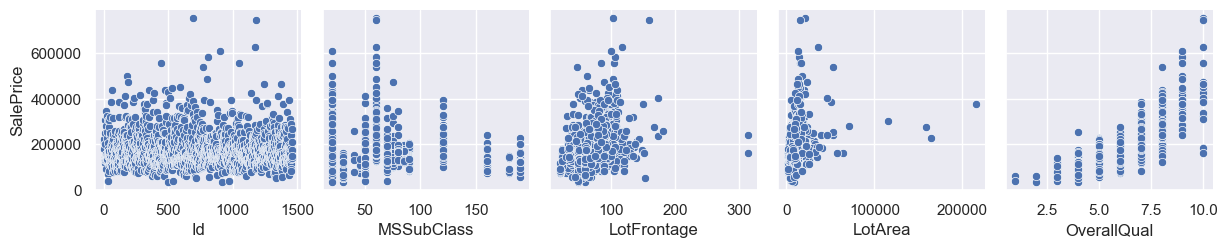

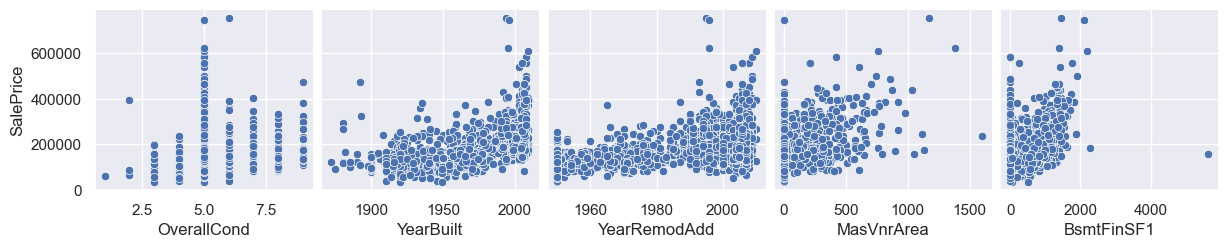

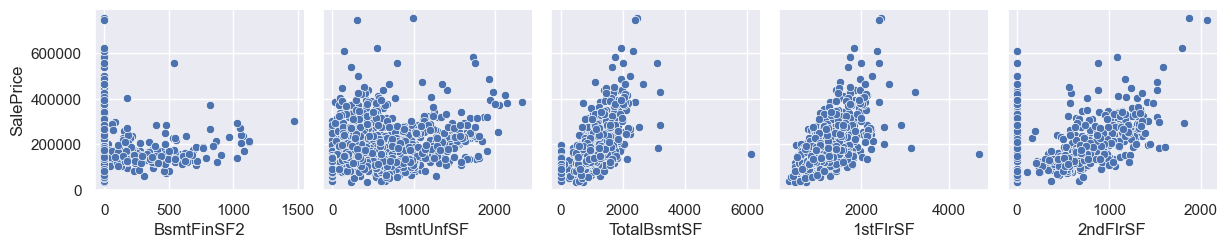

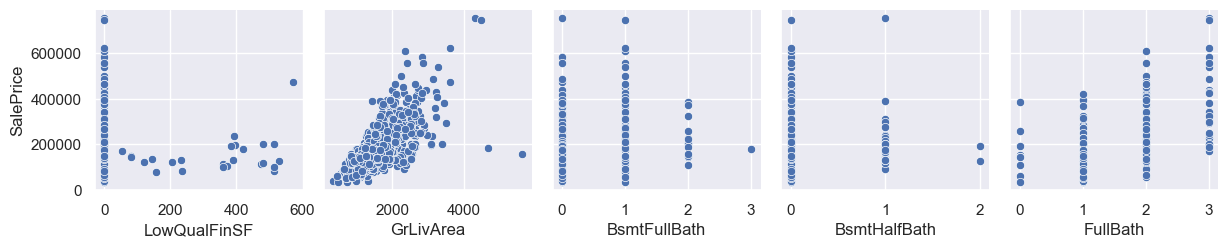

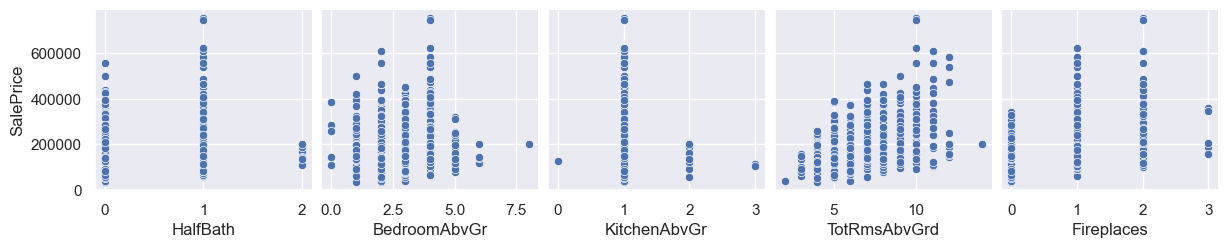

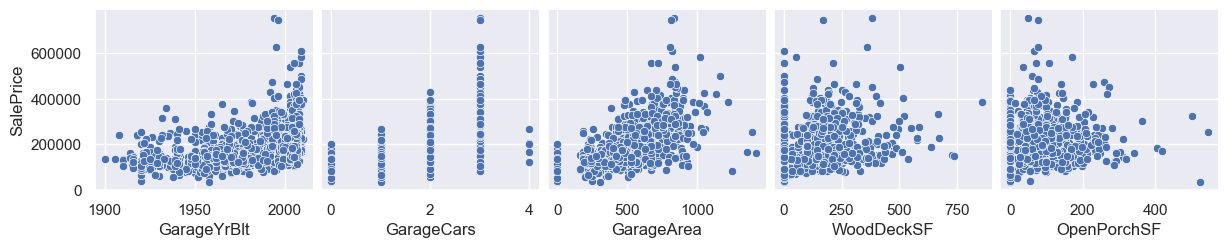

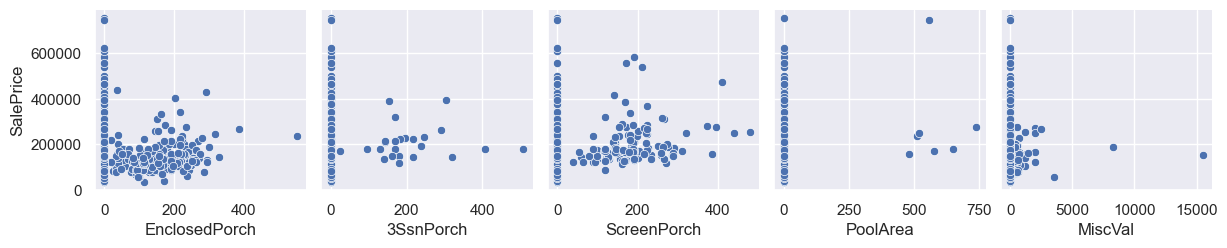

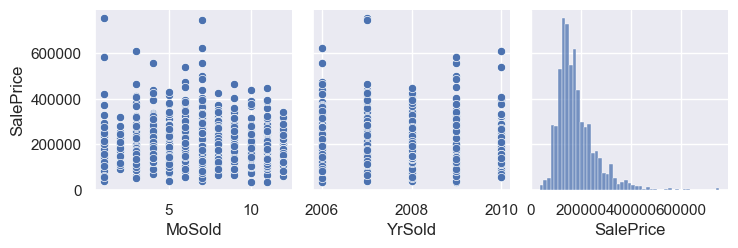

In [60]:
for i in range(0, len(df_num.columns), 5):
    sns.pairplot(data=df_num,
                x_vars=df_num.columns[i:i+5],
                y_vars=['SalePrice'])

We can clearly identify some relationships. Most of them seems to have a linear relationship with the SalePrice and if we look closely at the data we can see that a lot of data points are located on x = 0 which may indicate the absence of such feature in the house.